In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data',header=None,sep=r'\s+')
df.columns =  ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
corr_matrix = df.corr()
corr_medv = corr_matrix[['MEDV']].sort_values(by='MEDV',ascending=False)
corr_medv

,MEDV
MEDV,1.000000
RM,0.695360
ZN,0.360445
B,0.333461
DIS,0.249929
CHAS,0.175260
AGE,-0.376955
RAD,-0.381626
CRIM,-0.388305
NOX,-0.427321


In [4]:
cols = corr_medv.index.tolist()
cols.remove('MEDV')
cols

['RM',
 'ZN',
 'B',
 'DIS',
 'CHAS',
 'AGE',
 'RAD',
 'CRIM',
 'NOX',
 'TAX',
 'INDUS',
 'PTRATIO',
 'LSTAT']

In [5]:
X = df[cols].values
y = df['MEDV'].values.reshape(-1,1)

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30)

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# CREAMOS LA RED NEURONAL

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input

In [10]:
red = Sequential()
inputs = Input(shape=(13,))
entrada = Dense(units=500,activation='relu')
oculta1 = Dense(units=500,activation='relu')
oculta2 = Dense(units=500,activation='relu')
salida = Dense(units=1,activation='relu')

red.add(entrada)
red.add(oculta1)
red.add(Dropout(0.5))
red.add(oculta2)
red.add(salida)

red

<Sequential name=sequential, built=False>

In [11]:
red.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [17]:
history = red.fit(X_train_scaled,y_train_scaled,epochs=5,batch_size=128,validation_split=0.3,validation_data=(X_test_scaled,y_test_scaled))

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.3928 - mae: 0.4302 - val_loss: 0.5420 - val_mae: 0.4990
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4042 - mae: 0.4316 - val_loss: 0.5415 - val_mae: 0.4996
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.4537 - mae: 0.4774 - val_loss: 0.5397 - val_mae: 0.4946
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4535 - mae: 0.4638 - val_loss: 0.5480 - val_mae: 0.5029
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.4350 - mae: 0.4572 - val_loss: 0.5444 - val_mae: 0.4999


In [18]:
loss, mae = red.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f'loss evaluate : {loss}')
print(f' mae evaluate : {mae}')

loss evaluate : 0.5444089770317078
 mae evaluate : 0.49993714690208435


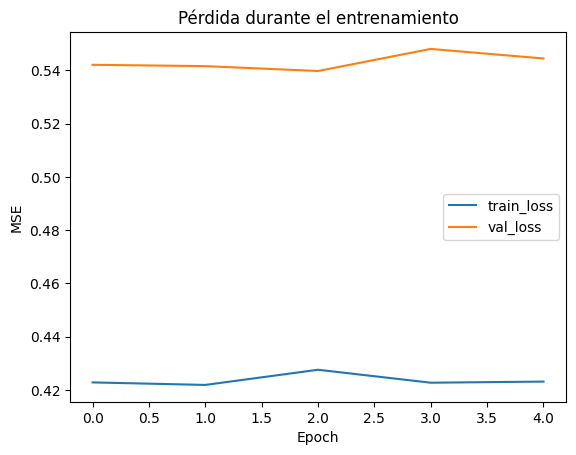

In [19]:
# 📈 Gráfico de pérdida
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Pérdida durante el entrenamiento')
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


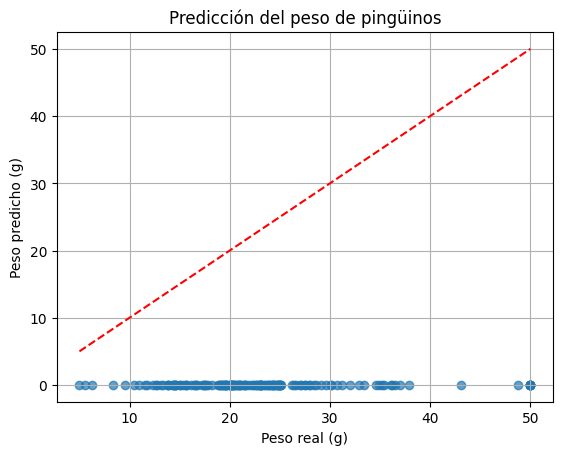

In [20]:
# 🔍 Predicciones
y_pred = red.predict(X_test).flatten()

# 📉 Comparar predicción vs valor real
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Peso real (g)')
plt.ylabel('Peso predicho (g)')
plt.title('Predicción del peso de pingüinos')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.grid(True)
plt.show()